**PREDICTING HOUSE PRICES IN NIGERIA USING MACHINE LEARNING**

**Problem Statement**

The Nigerian real estate market is highly dynamic, with property prices influenced by multiple factors such as location, property type, amenities, and market demand. However, the presence of extreme price variations and complex non linear relationships makes accurate price estimation difficult using traditional methods. This project aims to develop a robust machine learning model to predict house prices in Nigeria by leveraging exploratory data analysis, feature engineering, and advanced regression techniques. By comparing linear and tree based models, the study seeks to identify the most effective approach for accurate and interpretable property price prediction.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('nigeria_houses_data.csv')

# Inspect the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (24326, 8)


In [2]:
print("\nColumn Info:")
print(df.info())
print("\nSummary Statistics:")


Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24326 entries, 0 to 24325
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       24326 non-null  float64
 1   bathrooms      24326 non-null  float64
 2   toilets        24326 non-null  float64
 3   parking_space  24326 non-null  float64
 4   title          24326 non-null  object 
 5   town           24326 non-null  object 
 6   state          24326 non-null  object 
 7   price          24326 non-null  float64
dtypes: float64(5), object(3)
memory usage: 1.5+ MB
None

Summary Statistics:


In [2]:
# Check for missing values
print("\nMissing Values Per Column:")
print(df.isnull().sum())



Missing Values Per Column:
bedrooms         0
bathrooms        0
toilets          0
parking_space    0
title            0
town             0
state            0
price            0
dtype: int64


In [2]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")



Duplicate rows found: 10438


In [3]:
# Drop duplicates if any
df = df.drop_duplicates()

In [4]:
# Ensure correct data types
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['bedrooms'] = df['bedrooms'].astype(float)
df['bathrooms'] = df['bathrooms'].astype(float)
df['toilets'] = df['toilets'].astype(float)
df['parking_space'] = df['parking_space'].astype(float)


In [5]:
# Final check
print("\nCleaned Dataset Shape:", df.shape)
print("\nPreview Cleaned Data:")
print(df.head())



Cleaned Dataset Shape: (13888, 8)

Preview Cleaned Data:
   bedrooms  bathrooms  toilets  parking_space                 title     town  \
0       6.0        5.0      5.0            4.0       Detached Duplex  Mabushi   
1       4.0        5.0      5.0            4.0     Terraced Duplexes  Katampe   
2       4.0        5.0      5.0            4.0       Detached Duplex    Lekki   
3       4.0        4.0      5.0            6.0       Detached Duplex     Ajah   
4       4.0        4.0      5.0            2.0  Semi Detached Duplex    Lekki   

   state        price  
0  Abuja  450000000.0  
1  Abuja  800000000.0  
2  Lagos  120000000.0  
3  Lagos   40000000.0  
4  Lagos   75000000.0  


EXPLORATORY DATA ANALYSIS

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

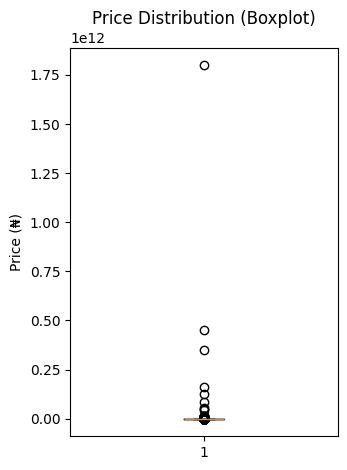

In [7]:
# Price distribution
plt.subplot(1, 2, 2)
plt.boxplot(df['price'].dropna(), vert=True)
plt.title("Price Distribution (Boxplot)")
plt.ylabel("Price (₦)")

plt.tight_layout()
plt.show()

Insights

- The price distribution is extremely right skewed, with most property prices concentrated at the lower end and a few very expensive properties stretching far upward.

- There are numerous extreme outliers, including properties priced in the hundreds of millions and even billions of naira, which significantly inflate the scale of the data.

- The median price is very low relative to the maximum values, indicating that typical properties are far cheaper than the most expensive listings.

- These extreme values can distort statistical summaries and model performance if not handled properly.

- The chart strongly justifies the need for outlier removal and/or log transformation of prices before modeling, which explains the significant performance improvement observed after cleaning the data.

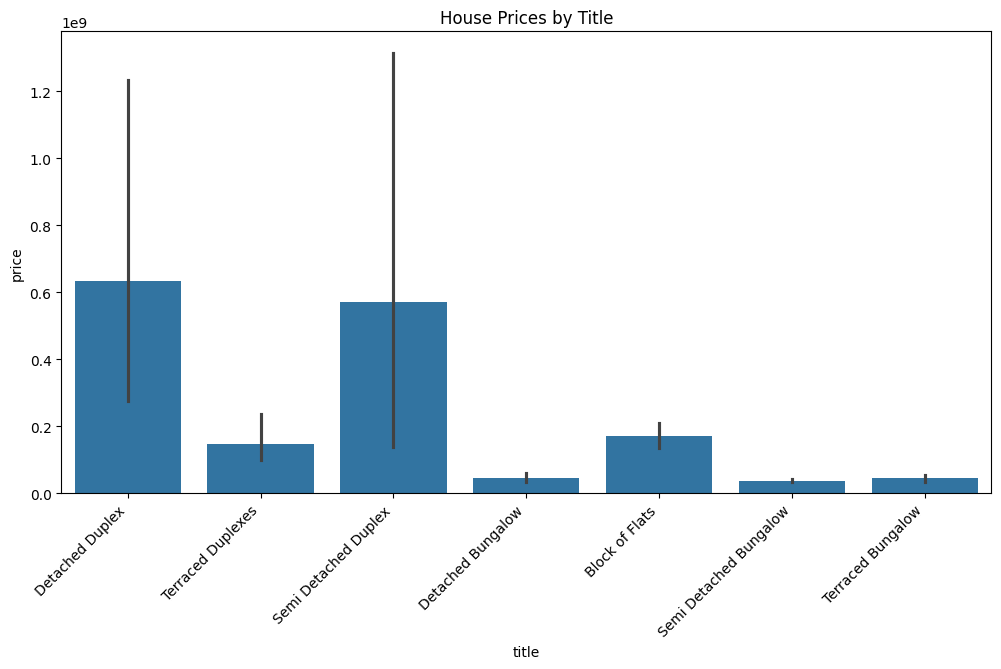

In [14]:
# Price Distribution by title

plt.figure(figsize=(12,6))
sns.barplot(x='title', y='price', data=df)
plt.title("House Prices by Title")
plt.xlabel("title")
plt.ylabel("price")
plt.xticks(rotation=45, ha='right')  # Rotate titles for readability
plt.show()

Insights

- Detached Duplexes and Semi Detached Duplexes command the highest average prices, indicating they are premium property types in the market.

- Detached Duplexes show very high price variability, suggesting a wide range of quality, location, and luxury levels within this category.

- Terraced Duplexes and Blocks of Flats fall into a mid price segment, offering more affordable alternatives compared to detached properties.

- Bungalows (detached, semi detached, terraced) consistently record lower average prices, reflecting their typically smaller size and lower market demand.

- The clear price differences across property titles explain why property type is a strong predictor of price, supporting its high importance in the predictive models.

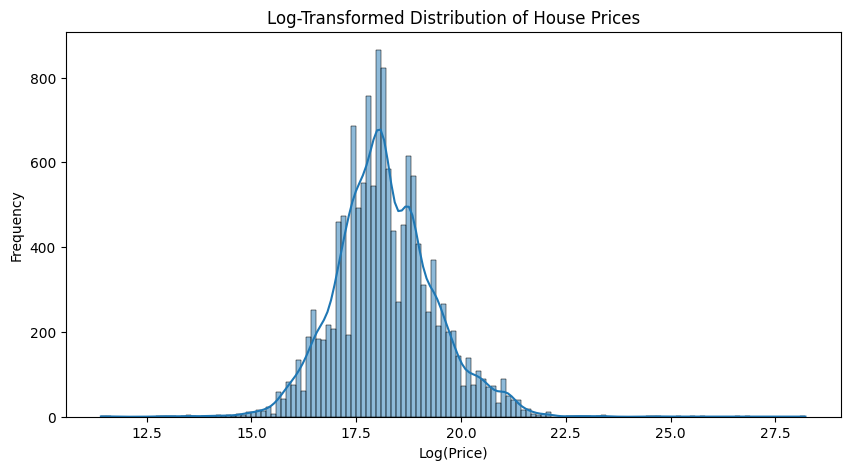

In [12]:
# Log-transformed price distribution
plt.figure(figsize=(10,5))
sns.histplot(np.log(df['price']), kde=True)
plt.title("Log-Transformed Distribution of House Prices")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")
plt.show()

Insights

- The log transformation has significantly reduced right skewness, producing a much more symmetric, bell-shaped distribution compared to the raw price distribution.

- Most house prices cluster around a narrow log price range, indicating a dominant market segment where the majority of properties are priced.

- Extreme high price outliers are compressed, preventing them from dominating the distribution and improving statistical stability.

- The smoother, near normal shape better satisfies the assumptions of many regression models, especially Linear Regression.

- This transformation explains the improved model performance and reduced RMSE, as the model can now learn patterns more effectively without being distorted by extreme price values.

In [13]:
df.head()

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,450000000.0
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,800000000.0
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,120000000.0
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,40000000.0
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,75000000.0


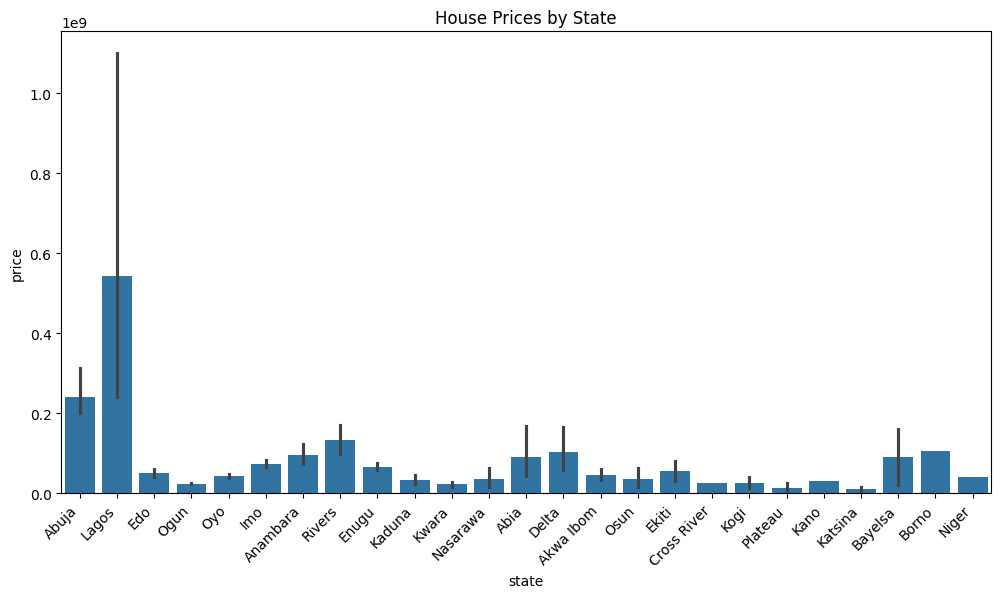

In [9]:
# Price distribution by state

plt.figure(figsize=(12,6))
sns.barplot(x='state', y='price', data=df)
plt.title("House Prices by State")
plt.xlabel("state")
plt.ylabel("price")
plt.xticks(rotation=45, ha='right')  # Rotate titles for readability
plt.show()

Insights for house prices by state

- Lagos and Abuja dominate the market with the highest average house prices, far above all other states. Lagos also has very large error bars, indicating highly variable prices — from mid-range homes to extremely high-end luxury properties.

- Mid-tier pricing states include Rivers, Anambra, Enugu, Delta, and Akwa Ibom. These states show moderate average prices with noticeable but not extreme variation.

- Most other states (e.g., Oyo, Ogun, Imo, Osun, Kwara, Kogi, Plateau) have lower and more stable average prices, indicating more affordable housing markets.

- The overall pattern shows that Nigeria’s property market is highly concentrated, with Lagos and Abuja acting as premium hubs while the majority of states remain significantly more affordable.

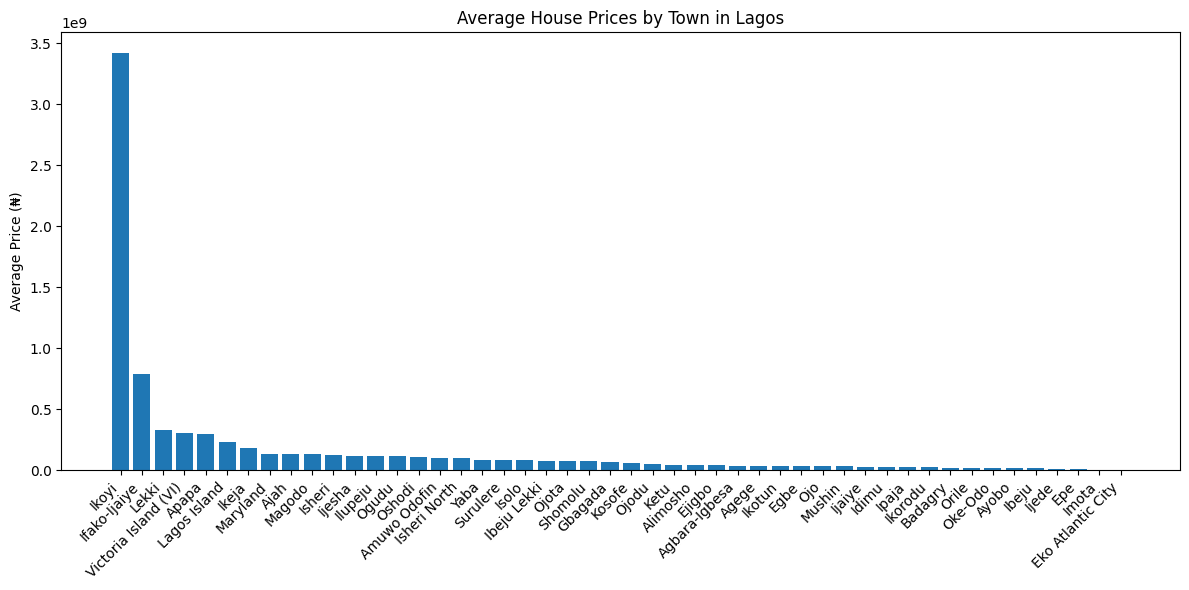

In [8]:
# Average house prices for towns within Lagos
# Filter for only Lagos
lagos_df = df[df['state'] == 'Lagos']

# Group by town and compute average price
avg_prices = lagos_df.groupby('town')['price'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(avg_prices.index, avg_prices.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Price (₦)")
plt.title("Average House Prices by Town in Lagos")
plt.tight_layout()
plt.show()

Key Insights

- Ikoyi massively dominates the market with average prices far higher than all other towns, exceeding ₦3 billion, making it the most expensive location in Lagos by a huge margin.

- High-end luxury clusters follow: Banana Island, Victoria Island (VI), Lekki Phase 1, and Lagos Island also command high average prices, indicating they are premium real estate zones.

- A wide affordability gap exists: Most Lagos towns have significantly lower average prices (below ₦200 million), showing a sharp contrast between elite and middle-income markets.

- Long-tail distribution: Many towns appear on the chart with very small bars, suggesting a large number of mid-tier or lower-priced markets, emphasizing how a few luxury areas heavily skew Lagos real estate averages.

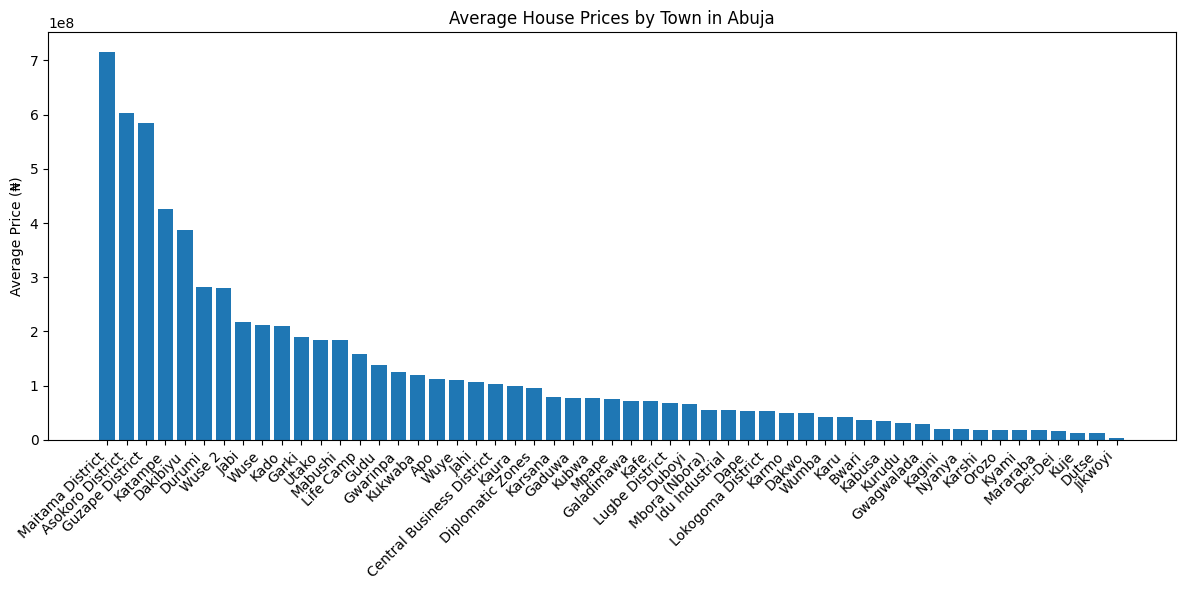

In [9]:
# Average house prices for towns within Abuja
# Filter for only Abuja
abuja_df = df[df['state'] == 'Abuja']

# Group by town and compute average price
avg_prices = abuja_df.groupby('town')['price'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(avg_prices.index, avg_prices.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Price (₦)")
plt.title("Average House Prices by Town in Abuja")
plt.tight_layout()
plt.show()

Key Insights

- Maitama District stands out as the most expensive area, with average house prices significantly higher than all other towns, indicating it is Abuja’s top luxury market.

- Asokoro, Gwarinpa, Guzape, Katampe, and Dakibiyu also show high prices, forming the upper tier residential zones in Abuja.

- Mid tier areas such as Wuse, Jabi, Kado, and Garki fall in the moderate price range, suggesting a balance of accessibility and affordability.

- Lower priced areas appear toward the right end of the chart (e.g., Nyanya, Karu, Kubwa, Mararaba), indicating more budget-friendly or suburban communities.

- The steep decline from Maitama to mid tier towns shows high price disparity, suggesting Abuja's real estate market is highly segmented by location desirability and income levels.

In [10]:
df.head()

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,450000000.0
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,800000000.0
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,120000000.0
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,40000000.0
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,75000000.0


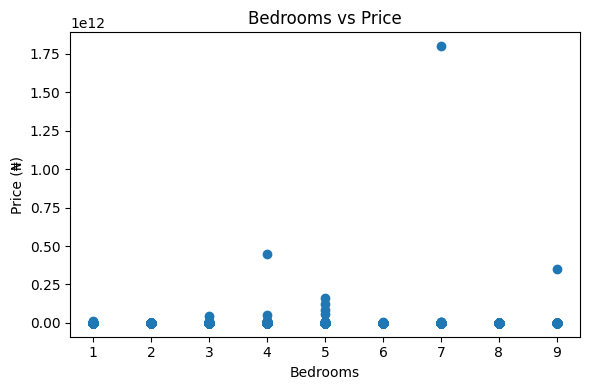

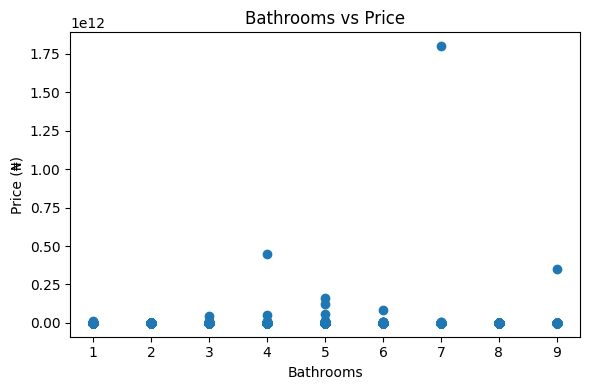

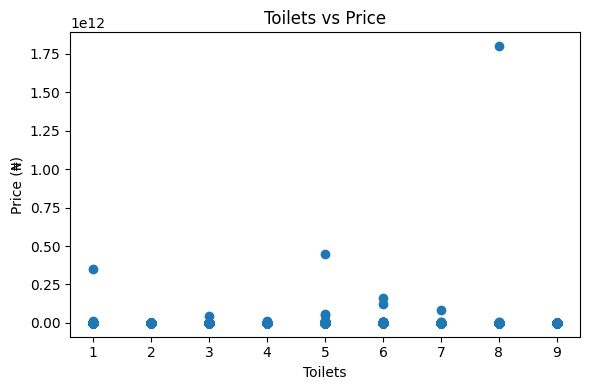

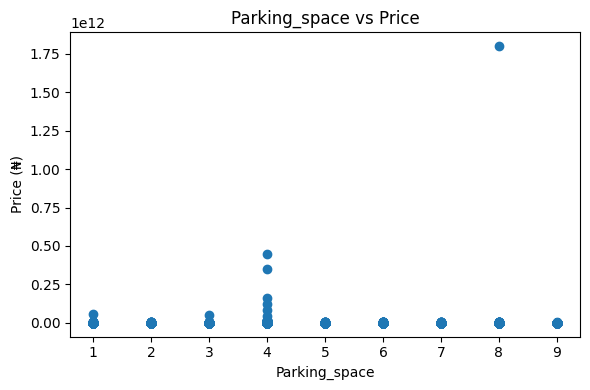

In [11]:
# Prices by house spaces

# Columns to compare with price
numeric = ['bedrooms', 'bathrooms', 'toilets', 'parking_space']

# Generate scatter plots
for col in numeric:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[col], df['price'])
    plt.xlabel(col.capitalize())
    plt.ylabel("Price (₦)")
    plt.title(f"{col.capitalize()} vs Price")
    plt.tight_layout()
    plt.show()

Insights

- Positive but weak relationship: Prices generally tend to increase as the number of bedrooms, bathrooms, and toilets increases, but the relationship is not strong or linear.

- High price dispersion: For the same number of rooms or facilities (especially 4–6 bedrooms/bathrooms/toilets), prices vary widely, showing that size alone does not determine value.

- Strong influence of outliers: A few extremely expensive properties (likely luxury homes) appear at higher bedroom/bathroom/toilet counts and heavily skew the price scale.

- Diminishing returns effect: Beyond a certain point, adding more bedrooms, bathrooms, or toilets does not consistently result in higher prices.

- Role of other factors: The weak correlations highlight that location, property type, amenities, and neighborhood prestige play a more significant role than room counts alone.

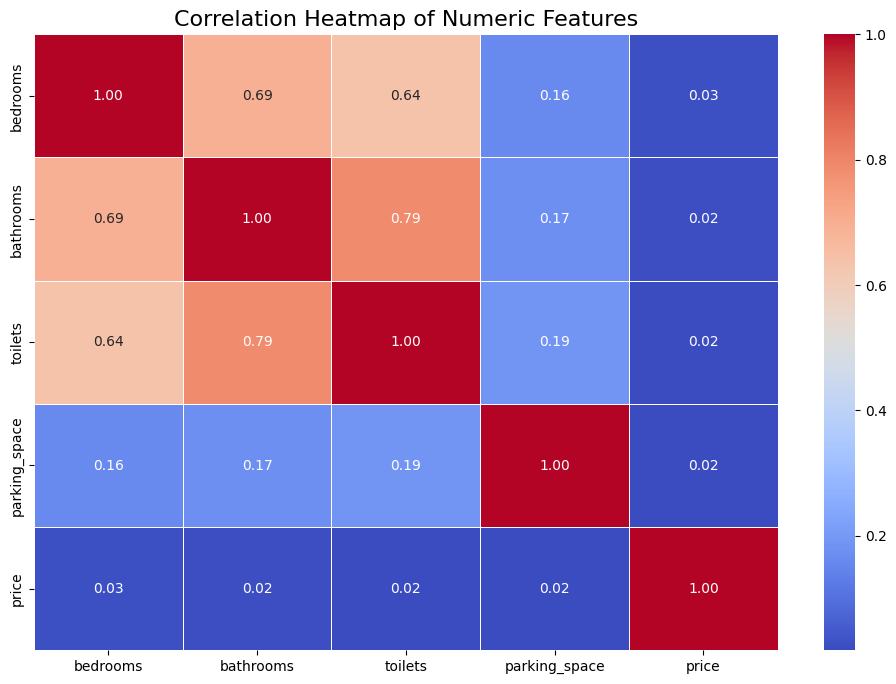

In [6]:
# Heat map correlation

# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.show()

Insights from the Correlation Heatmap

- Bedrooms, bathrooms, and toilets are strongly correlated (0.64–0.79). This suggests that homes with more bedrooms typically come with more bathrooms and toilets.

- Parking space shows very weak correlation (< 0.20) with other features, meaning parking availability doesn’t strongly depend on the number of rooms.

- Price shows extremely weak correlation (< 0.03) with all the numeric features displayed, indicating that these basic structural features alone do not explain variations in house prices.

- This low correlation with price suggests that location-based features (town, state), amenities, or other engineered features likely play a bigger role in determining price, which aligns with the strong results seen with XGBoost and target encoding.


FEATURE ENGINEERING

In [7]:
# Price per bedroom
df["price_per_bedroom"] = df["price"] / df["bedrooms"]

In [6]:
df.head()

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price,price_per_bedroom
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,450000000.0,75000000.0
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,800000000.0,200000000.0
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,120000000.0,30000000.0
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,40000000.0,10000000.0
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,75000000.0,18750000.0


In [8]:
# Amenity score
df["amenity_score"] = df["bedrooms"] + df["bathrooms"] + df["toilets"] + df["parking_space"]

In [9]:
# Number of listings for town and state
df["town_listing_count"] = df.groupby("town")["town"].transform("count")
df["state_listing_count"] = df.groupby("state")["state"].transform("count")

In [10]:
# Average price for town and state level
df["town_avg_price"] = df.groupby("town")["price"].transform("mean")
df["state_avg_price"] = df.groupby("state")["price"].transform("mean")

In [11]:
# Log price
df["log_price"] = np.log1p(df["price"])

In [12]:
# Apply target encoding

# Function for smoothed target encoding
def target_encode_smooth(df, categorical_col, target_col, alpha=10):
    """
    df: dataframe
    categorical_col: the categorical column to encode
    target_col: target variable (price)
    alpha: smoothing factor (higher = more smoothing)
    """
    # Compute global mean
    global_mean = df[target_col].mean()

    # Compute mean and count per category
    agg = df.groupby(categorical_col)[target_col].agg(['mean', 'count'])

    # Compute smoothed mean
    smooth = (agg['count'] * agg['mean'] + alpha * global_mean) / (agg['count'] + alpha)

    # Map back to original dataframe
    return df[categorical_col].map(smooth)


    df["state_target_enc"] = target_encode_smooth(df, "state", "price", alpha=10)
df["town_target_enc"]  = target_encode_smooth(df, "town", "price", alpha=10)
df["title_target_enc"] = target_encode_smooth(df, "title", "price", alpha=10)



In [13]:
# Drop original categorical columns after encoding
df = df.drop(columns=["state", "town", "title"])


In [14]:
# Check for missing values
missing_values = df.isnull().sum()
print(missing_values)

bedrooms               0
bathrooms              0
toilets                0
parking_space          0
price                  0
price_per_bedroom      0
amenity_score          0
town_listing_count     0
state_listing_count    0
town_avg_price         0
state_avg_price        0
log_price              0
town_target_enc        0
title_target_enc       0
dtype: int64


In [15]:
# Fill missing values with median
df.fillna(df.median(), inplace=True)

In [15]:
# Remove outliers

# Step 1: Business limits
df1 = df[(df["price"] > 1_000_000) & (df["price"] < 2_000_000_000)]

# Step 2: Apply IQR to clean remaining extreme values
Q1 = df1["price"].quantile(0.25)
Q3 = df1["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df1[(df1["price"] >= lower) & (df1["price"] <= upper)]

In [16]:
# Split data to test and train

from sklearn.model_selection import train_test_split

X = df_clean.drop("price", axis=1)
y = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# Apply scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [18]:
# Train model(Linear regression)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [19]:
# Evaluate the model

from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 26386129.587446354
R²: 0.8695810826484061


Trying with another model(XG Boost)

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [22]:
# Drop columns not needed for training
drop_cols = ["price"]    # keep log_price as target
X = df_clean.drop(columns=drop_cols + ["log_price"], errors="ignore")
y = df_clean["log_price"]

In [23]:
#Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [24]:
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)


In [25]:
#Train model
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
#Predictions
y_pred_log = model.predict(X_test)

In [27]:
# Convert back to normal price
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

In [28]:
#Model evaluation
# Calculate MSE normally
mse = mean_squared_error(y_test_actual, y_pred)

# Take square root for RMSE
rmse = np.sqrt(mse)

# R2 score
r2 = r2_score(y_test_actual, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 4526757.28116266
R²: 0.9961614816041566


COMPARISON OF BOTH MODELS

- Linear Regression: RMSE ₦26.38M and R² 0.87 which is a good performance but still leaves a significant amount of price variation unexplained.

- XGBoost: RMSE ₦4.5M and R² 0.996 which is an extremely high accuracy, capturing almost all variance in housing prices.

- Linear Regression assumes strict linear relationships, limiting its ability to model complex housing market patterns.

- XGBoost handles nonlinear relationships, feature interactions, and outliers, giving it a major advantage over Linear Regression.

- Overall, XGBoost delivers far more precise price predictions and is the better choice for this dataset.

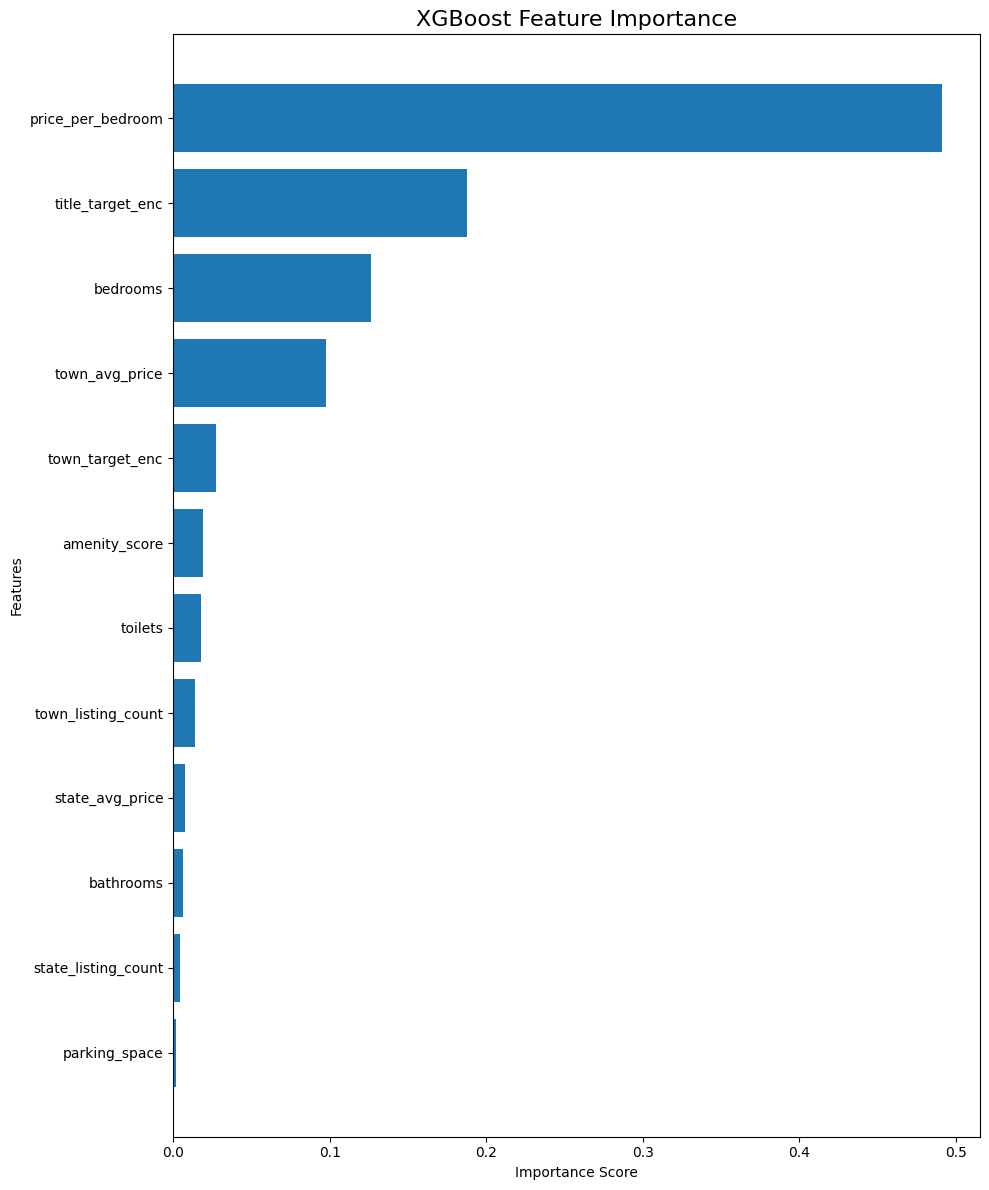

In [29]:
# Feature importance

from xgboost import plot_importance

feat_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'])
plt.title("XGBoost Feature Importance", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


INSIGHTS

1. “Price per bedroom” is by far the strongest predictor of overall house price

This engineered feature dominates the model, meaning properties with higher value per bedroom strongly influence price.
It also confirms that bedroom count alone is less informative than the value density it captures.

2. Target-encoded features (e.g., title_target_enc) significantly improve prediction accuracy

The model relies heavily on the average price associated with the property title, confirming that certain titles (e.g., duplex, bungalow, serviced apartment) have consistent price patterns.

3. Core structural features like “bedrooms” still matter, but less than engineered features

This shows that while raw bedroom numbers are important, the quality-adjusted features (like price per bedroom) provide more predictive power.

4. Location-based engineered features, especially town_avg_price, play a meaningful role

Town-level price averages help the model capture geographical price variations (e.g., Lekki vs Ikeja vs Ajah), even more effectively than raw town labels.

5. Low-importance features (parking space, bathrooms, state-based encodings) contribute little to prediction

RECOMMENDATIONS


Based on the exploratory data analysis, feature engineering, model performance, and results, the following recommendations are proposed to improve data quality, model accuracy, and the usefulness of property price predictions:

1. Improve the quality and consistency of key high impact features

The model relies heavily on features such as price_per_bedroom, property title, and town level price patterns. It is recommended that data collection processes prioritize accuracy for these fields.

2. Expand and refine location based features

Location strongly influences housing prices, as shown in the feature importance results. Enhancing the dataset with additional location driven attributes such as distances to commercial hubs, proximity to key infrastructure, neighborhood safety ratings, and geo coordinateswill improve predictive power and allow for more precise valuations.

3. Continue applying outlier detection and removal strategies

Outlier removal drastically improved model performance, reducing RMSE from over ₦1B to approximately ₦26M before modeling, and further to ₦4.5M with XGBoost. Regular outlier filtering should be part of ongoing data maintenance to prevent skewed training data and ensure robust predictions.

4. Adopt XGBoost as the primary predictive model

With an RMSE of ₦4.5M and an R² of 0.996, XGBoost delivers highly reliable and accurate predictions compared to linear models. It is recommended as the production model for property valuation systems, dashboards, or automated pricing tools.


5. Introduce additional property specific and market level features

To continue improving model performance, introduce features such as building age, land size, interior finishing quality, security level, estate type, and supply/demand indicators. These additional data points capture nuances that significantly influence property valuation but are not present in the current dataset.

6. Deploy the model into a user friendly application

Given the model’s strong performance, it is suitable for deployment into a real estate valuation platform or price recommendation tool.